# CNN Quantization
Baseline: `conv_layers=1, filters=8, kernel=3, dense=16, dropout=0.3, batch=32, lr=0.001`

Three TFLite quantization strategies are evaluated:
1. **Float16** — half-precision weights, minimal accuracy loss
2. **Dynamic Range** — int8 weights, float activations (no representative dataset needed)
3. **Full Integer (INT8)** — weights + activations quantized, smallest model, MCU-ready

In [ ]:
# =========================
# SETUP
# =========================
import os, tempfile, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                             recall_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from google.colab import drive

drive.mount('/content/drive')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

DATA_PATH  = "/content/drive/MyDrive/SisFall_dataset/dataset_exp4_v4_final.npz"
BASELINE_DIR = "/content/drive/MyDrive/M3_Project/final_cnn_sisfall_v2"
SAVE_DIR   = "/content/drive/MyDrive/cnn_quantized"
os.makedirs(SAVE_DIR, exist_ok=True)

data = np.load(DATA_PATH, allow_pickle=True)
X_train, X_val, X_test = data["X_train"], data["X_val"], data["X_test"]
y_train, y_val, y_test = data["y_train"], data["y_val"], data["y_test"]

# Load best threshold from baseline
with open(os.path.join(BASELINE_DIR, "best_threshold.txt")) as f:
    THRESHOLD = float(f.read().strip())
print(f"Using threshold: {THRESHOLD:.2f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using threshold: 0.85


In [ ]:
# =========================
# LOAD BASELINE MODEL
# =========================
model = tf.keras.models.load_model(os.path.join(BASELINE_DIR, "final_cnn_v2.keras"))
model.summary()

# Baseline metrics for comparison
base_probs = model.predict(X_test, verbose=0).ravel()
base_pred  = (base_probs >= THRESHOLD).astype(int)
BASE_ACC   = accuracy_score(y_test, base_pred)
BASE_F1    = f1_score(y_test, base_pred, zero_division=0)
BASE_PREC  = precision_score(y_test, base_pred, zero_division=0)
BASE_REC   = recall_score(y_test, base_pred, zero_division=0)
print(f"\nBaseline  |  Acc={BASE_ACC:.4f}  F1={BASE_F1:.4f}  "
      f"Prec={BASE_PREC:.4f}  Rec={BASE_REC:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 50, 8)          │           152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 8)          │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 8)              │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,005 (3.93 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 16 (64.00 B)

 Optimizer params: 660 (2.58 KB)


Baseline  |  Acc=0.9922  F1=0.9669  Prec=0.9564  Rec=0.9777


In [ ]:
# =========================
# HELPERS
# =========================
def tflite_size_kb(tflite_bytes):
    tmp = tempfile.mktemp(suffix=".tflite")
    with open(tmp, "wb") as f: f.write(tflite_bytes)
    kb = os.path.getsize(tmp) / 1024
    os.remove(tmp)
    return round(kb, 2)


def run_tflite_inference(tflite_bytes, X):
    """Run TFLite model on X, return probabilities (float)."""
    interp = tf.lite.Interpreter(model_content=tflite_bytes)
    interp.allocate_tensors()
    inp  = interp.get_input_details()[0]
    out  = interp.get_output_details()[0]

    # Detect if input expects int8
    is_int8 = (inp['dtype'] == np.int8)
    scale, zero_point = inp['quantization']

    probs = []
    for i in range(len(X)):
        sample = X[i:i+1].astype(np.float32)
        if is_int8:
            sample = np.clip(np.round(sample / scale + zero_point),
                             -128, 127).astype(np.int8)
        interp.set_tensor(inp['index'], sample)
        interp.invoke()
        raw = interp.get_tensor(out['index'])
        # Dequantize output if int8
        if out['dtype'] == np.int8:
            o_scale, o_zp = out['quantization']
            raw = (raw.astype(np.float32) - o_zp) * o_scale
        probs.append(float(raw.ravel()[0]))
    return np.array(probs)


def evaluate_tflite(name, tflite_bytes, X, y_true, threshold):
    probs  = run_tflite_inference(tflite_bytes, X)
    y_pred = (probs >= threshold).astype(int)
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    kb     = tflite_size_kb(tflite_bytes)
    print(f"{name:<25} | Size={kb:7.2f} KB | Acc={acc:.4f}  "
          f"F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}")
    return dict(name=name, size_kb=kb, acc=acc, f1=f1,
                prec=prec, rec=rec, probs=probs, y_pred=y_pred)


# Representative dataset generator (used by INT8 full quantization)
def make_rep_dataset(X, n=200):
    idx = np.random.choice(len(X), n, replace=False)
    subset = X[idx].astype(np.float32)
    def generator():
        for s in subset:
            yield [s[np.newaxis, ...]]
    return generator

In [ ]:
# =========================
# 1. FLOAT16 QUANTIZATION
# =========================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_f16 = converter.convert()

with open(os.path.join(SAVE_DIR, "cnn_float16.tflite"), "wb") as f:
    f.write(tflite_f16)

print("Float16 quantization complete.")

Saved artifact at '/tmp/tmp2l41lzas'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138864678333392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678336080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678336848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678334736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678335120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678332240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678337808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678338000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678331088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678338192: TensorSpec(shape=(), dtype=tf.resource, name=None)
Float16 quantization co

In [ ]:
# =========================
# 2. DYNAMIC RANGE QUANTIZATION
# =========================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
# No target_spec → dynamic range (int8 weights, float activations)

tflite_dyn = converter.convert()

with open(os.path.join(SAVE_DIR, "cnn_dynamic_range.tflite"), "wb") as f:
    f.write(tflite_dyn)

print("Dynamic range quantization complete.")

Saved artifact at '/tmp/tmp8hw76156'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138864678333392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678336080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678336848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678334736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678335120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678332240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678337808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678338000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678331088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678338192: TensorSpec(shape=(), dtype=tf.resource, name=None)
Dynamic range quantizat

In [ ]:
# =========================
# 3. FULL INTEGER (INT8) QUANTIZATION
# =========================
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = make_rep_dataset(X_train)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type  = tf.int8
converter.inference_output_type = tf.int8

tflite_int8 = converter.convert()

with open(os.path.join(SAVE_DIR, "cnn_int8.tflite"), "wb") as f:
    f.write(tflite_int8)

print("Full INT8 quantization complete.")

Saved artifact at '/tmp/tmp8ocd2ag_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138864678333392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678336080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678336848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678334736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678335120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678332240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678337808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678338000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678331088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678338192: TensorSpec(shape=(), dtype=tf.resource, name=None)
Full INT8 quantization 

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
# =========================
# EVALUATE ALL VARIANTS
# =========================
print(f"{'Model':<25} | {'Size':>10} | Metrics")
print("-" * 75)

# Baseline (Keras float32)
import tempfile
tmp_path = tempfile.mktemp(suffix=".tflite")
conv = tf.lite.TFLiteConverter.from_keras_model(model)
base_tflite = conv.convert()
print(f"{'Baseline (float32)':<25} | Size={tflite_size_kb(base_tflite):7.2f} KB | "
      f"Acc={BASE_ACC:.4f}  F1={BASE_F1:.4f}  Prec={BASE_PREC:.4f}  Rec={BASE_REC:.4f}")

results = []
results.append(evaluate_tflite("Float16",       tflite_f16,  X_test, y_test, THRESHOLD))
results.append(evaluate_tflite("Dynamic Range", tflite_dyn,  X_test, y_test, THRESHOLD))
results.append(evaluate_tflite("Full INT8",     tflite_int8, X_test, y_test, THRESHOLD))

Model                     |       Size | Metrics
---------------------------------------------------------------------------
Saved artifact at '/tmp/tmpoc2glwu_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 6), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  138864678333392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678336080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678336848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678334736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678335120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678332240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678337808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678338000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138864678331088: TensorSpec(shape=()

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use 

In [ ]:
# =========================
# SUMMARY TABLE
# =========================
base_kb = tflite_size_kb(base_tflite)

print("\n" + "="*70)
print("QUANTIZATION SUMMARY")
print("="*70)
print(f"{'Model':<22} {'Size(KB)':>9} {'Reduction':>11} {'Acc':>8} {'F1':>8} {'Recall':>8}")
print("-"*70)
print(f"{'Baseline (float32)':<22} {base_kb:9.2f} {'—':>11} {BASE_ACC:8.4f} {BASE_F1:8.4f} {BASE_REC:8.4f}")
for r in results:
    reduction = f"{(1 - r['size_kb']/base_kb)*100:.1f}%"
    print(f"{r['name']:<22} {r['size_kb']:9.2f} {reduction:>11} {r['acc']:8.4f} {r['f1']:8.4f} {r['rec']:8.4f}")


QUANTIZATION SUMMARY
Model                   Size(KB)   Reduction      Acc       F1   Recall
----------------------------------------------------------------------
Baseline (float32)          5.86           —   0.9922   0.9669   0.9777
Float16                     6.12       -4.4%   0.9922   0.9669   0.9777
Dynamic Range               5.86        0.0%   0.9922   0.9669   0.9777
Full INT8                   6.29       -7.3%   0.9586   0.8421   0.9517


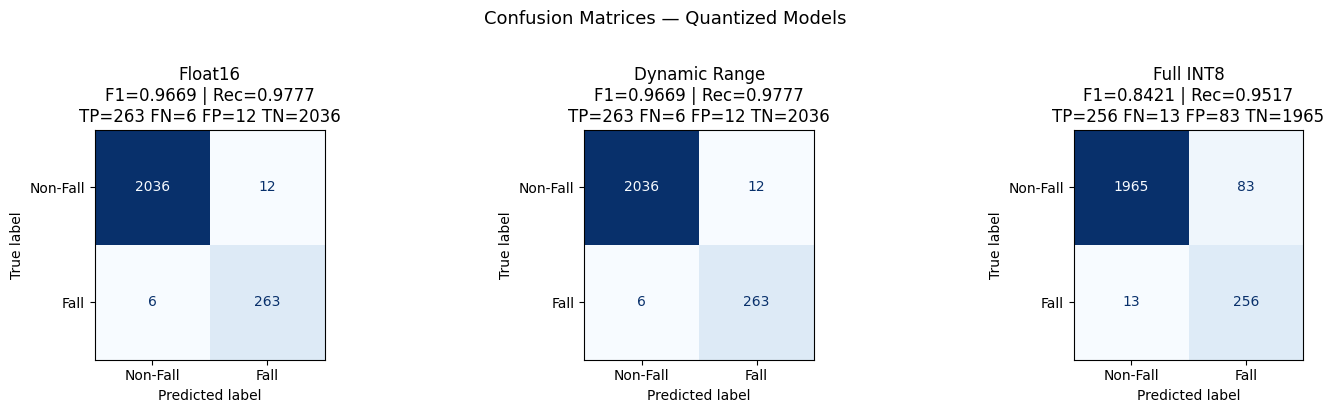

In [ ]:
# =========================
# CONFUSION MATRICES
# =========================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
names = ["Float16", "Dynamic Range", "Full INT8"]

for ax, r in zip(axes, results):
    cm = confusion_matrix(y_test, r['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=["Non-Fall", "Fall"]).plot(
        ax=ax, cmap="Blues", values_format="d", colorbar=False)
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{r['name']}\nF1={r['f1']:.4f} | Rec={r['rec']:.4f}\nTP={tp} FN={fn} FP={fp} TN={tn}")
    ax.grid(False)

plt.suptitle("Confusion Matrices — Quantized Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "quantization_confusion_matrices.png"), dpi=150, bbox_inches='tight')
plt.show()

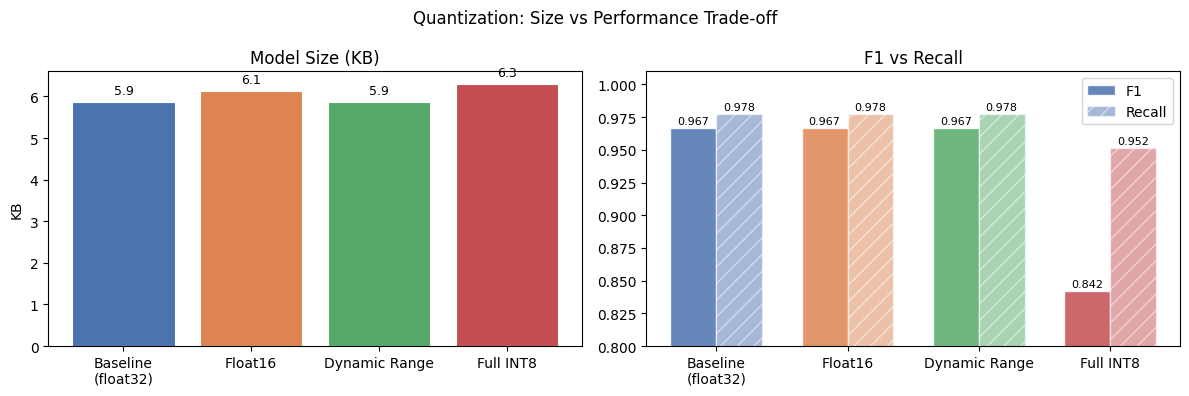

In [ ]:
# =========================
# SIZE vs ACCURACY PLOT
# =========================
all_names = ["Baseline\n(float32)"] + [r['name'] for r in results]
all_sizes = [base_kb] + [r['size_kb'] for r in results]
all_f1    = [BASE_F1]  + [r['f1']     for r in results]
all_rec   = [BASE_REC] + [r['rec']    for r in results]

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(all_names, all_sizes, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title("Model Size (KB)")
axes[0].set_ylabel("KB")
for i, v in enumerate(all_sizes):
    axes[0].text(i, v + 0.2, f"{v:.1f}", ha='center', fontsize=9)

x = np.arange(len(all_names))
width = 0.35
axes[1].bar(x - width/2, all_f1,  width, label='F1',     color=colors, alpha=0.85, edgecolor='white')
axes[1].bar(x + width/2, all_rec, width, label='Recall', color=colors, alpha=0.5,  edgecolor='white', hatch='//')
axes[1].set_xticks(x); axes[1].set_xticklabels(all_names)
axes[1].set_ylim(0.8, 1.01)
axes[1].set_title("F1 vs Recall")
axes[1].legend()
for i, (f, rc) in enumerate(zip(all_f1, all_rec)):
    axes[1].text(i - width/2, f  + 0.003, f"{f:.3f}",  ha='center', fontsize=8)
    axes[1].text(i + width/2, rc + 0.003, f"{rc:.3f}", ha='center', fontsize=8)

plt.suptitle("Quantization: Size vs Performance Trade-off", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "quantization_tradeoff.png"), dpi=150)
plt.show()

In [ ]:
# =========================
# SAVE THRESHOLD FILE FOR EACH VARIANT
# (threshold is unchanged — tuned on float32 validation probs)
# =========================
for name in ["cnn_float16", "cnn_dynamic_range", "cnn_int8"]:
    with open(os.path.join(SAVE_DIR, f"{name}_threshold.txt"), "w") as f:
        f.write(str(THRESHOLD))

print(f"All models saved to: {SAVE_DIR}")
print("Files written:")
for fn in sorted(os.listdir(SAVE_DIR)):
    path = os.path.join(SAVE_DIR, fn)
    print(f"  {fn}  ({os.path.getsize(path)/1024:.1f} KB)")

All models saved to: /content/drive/MyDrive/cnn_quantized
Files written:
  cnn_dynamic_range.tflite  (5.9 KB)
  cnn_dynamic_range_threshold.txt  (0.0 KB)
  cnn_float16.tflite  (6.1 KB)
  cnn_float16_threshold.txt  (0.0 KB)
  cnn_int8.tflite  (6.3 KB)
  cnn_int8_threshold.txt  (0.0 KB)
  quantization_confusion_matrices.png  (60.4 KB)
  quantization_tradeoff.png  (72.5 KB)
